In [3]:
import pandas as pd
df = pd.read_csv(r'data\network_logs.csv')
df.head()

,timestamp,device,interface,event,severity,ip,message
0,2026-05-06 22:11:52,router1,wlan0,packet_loss,WARNING,157.208.200.158,High packet loss detected on router1 (17%)
1,2026-05-06 22:11:33,router2,eth2,normal_traffic,INFO,91.242.8.223,router2 normal traffic flow stable
2,2026-05-06 22:16:23,switch2,wlan0,cpu_spike,WARNING,207.58.9.129,switch2 CPU usage at 95%
3,2026-05-06 22:13:30,router2,wlan0,normal_traffic,INFO,188.21.87.72,router2 normal traffic flow stable
4,2026-05-06 22:16:20,router2,wlan0,normal_traffic,INFO,105.25.193.79,router2 normal traffic flow stable


In [3]:
df.shape

(2000, 7)

In [4]:
df.dtypes

timestamp    str
device       str
interface    str
event        str
severity     str
ip           str
message      str
dtype: object

In [5]:
# Convert kolom timestamp ke tipe datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [6]:
df.dtypes

timestamp    datetime64[us]
device                  str
interface               str
event                   str
severity                str
ip                      str
message                 str
dtype: object

## Cleaning Data

In [7]:
# duplicated data
df.duplicated().sum()

np.int64(0)

In [8]:
# missing values
df.isnull().sum()

timestamp    0
device       0
interface    0
event        0
severity     0
ip           0
message      0
dtype: int64

## EDA

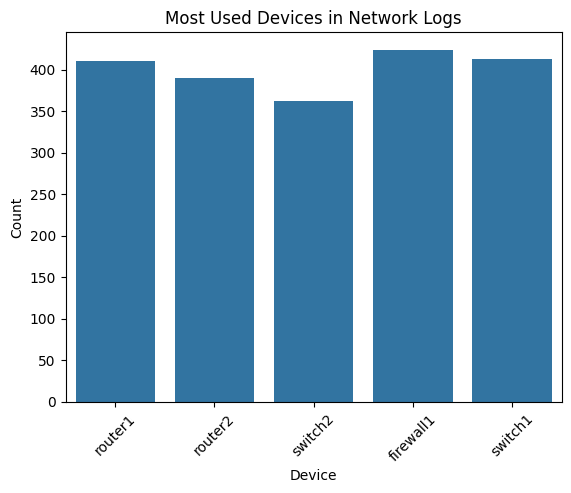

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Most device used
sns.countplot(x='device', data=df)
plt.title('Most Used Devices in Network Logs')
plt.xticks(rotation=45)
plt.xlabel('Device')
plt.ylabel('Count')
plt.show()

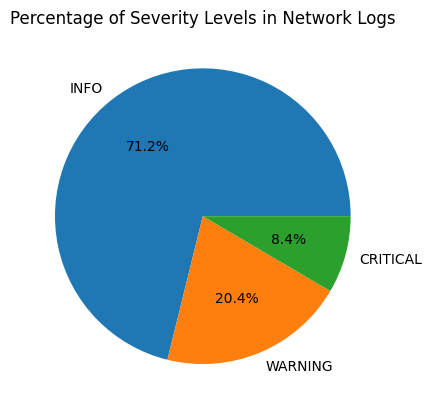

In [10]:
# Percentage of severity levels
severity_counts = df['severity'].value_counts()
label = severity_counts.index

plt.pie(severity_counts, labels=label, autopct='%1.1f%%')
plt.title('Percentage of Severity Levels in Network Logs')
plt.show()

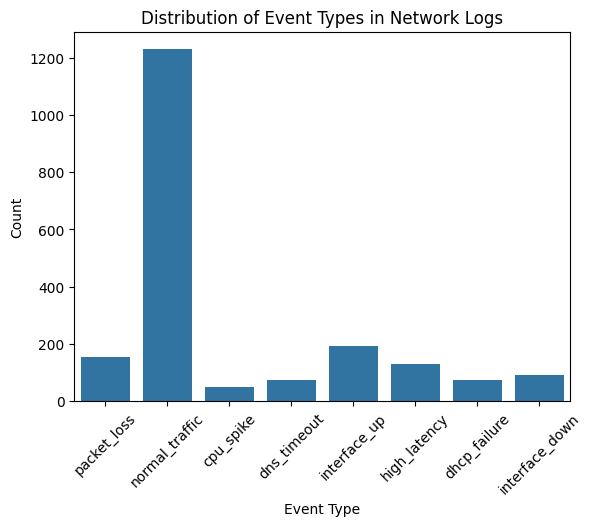

In [56]:
# Distribution of event types
sns.countplot(x='event', data=df)
plt.title('Distribution of Event Types in Network Logs')
plt.xticks(rotation=45)
plt.xlabel('Event Type')
plt.ylabel('Count')
plt.show()

## Convert Dataframe to Document

In [11]:
# Convert to document format
df['document'] = df.apply(lambda row: f"{row['timestamp']} - {row['device']} - {row['interface']} - {row['event']} - {row['severity']} - {row['ip']} - {row['message']}", axis=1)
documents = df['document'].tolist()

In [12]:
# display first 5 documents
for doc in documents[:5]:
    print(doc)

2026-05-06 22:11:52 - router1 - wlan0 - packet_loss - WARNING - 157.208.200.158 - High packet loss detected on router1 (17%)
2026-05-06 22:11:33 - router2 - eth2 - normal_traffic - INFO - 91.242.8.223 - router2 normal traffic flow stable
2026-05-06 22:16:23 - switch2 - wlan0 - cpu_spike - WARNING - 207.58.9.129 - switch2 CPU usage at 95%
2026-05-06 22:13:30 - router2 - wlan0 - normal_traffic - INFO - 188.21.87.72 - router2 normal traffic flow stable
2026-05-06 22:16:20 - router2 - wlan0 - normal_traffic - INFO - 105.25.193.79 - router2 normal traffic flow stable


## Embeddings

In [13]:
# Embedding model
from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
embeddings = embed_model.encode(documents, normalize_embeddings=True)

c:\Users\Arvio\anaconda3\envs\network_logs\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5056.34it/s]


## Vector Store

In [24]:
import faiss
import numpy as np

dim = embeddings.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(np.array(embeddings))
# save index to disk
faiss.write_index(index, 'faiss_index.idx')

In [25]:
# load index from disk
index = faiss.read_index('faiss_index.idx')

## LLM

In [15]:
# LLM Model
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_name = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    torch_dtype=torch.float16
)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 338/338 [00:01<00:00, 306.97it/s]


In [27]:
query = "give me 1 ip with warning severity !"
query_embedding = embed_model.encode([query], normalize_embeddings=True)

D, I = index.search(np.array(query_embedding), k=8)

context = "\n".join([documents[i] for i in I[0]])
print(context)

2026-05-06 22:11:49 - firewall1 - eth1 - packet_loss - WARNING - 192.107.140.186 - High packet loss detected on firewall1 (5%)
2026-05-06 22:11:35 - firewall1 - eth1 - packet_loss - WARNING - 184.48.69.220 - High packet loss detected on firewall1 (37%)
2026-05-06 22:12:54 - firewall1 - eth1 - packet_loss - WARNING - 42.61.68.159 - High packet loss detected on firewall1 (13%)
2026-05-06 22:16:06 - firewall1 - eth2 - high_latency - WARNING - 213.217.55.250 - Latency spike on firewall1 reaching 318ms
2026-05-06 22:12:37 - firewall1 - eth1 - packet_loss - WARNING - 36.203.202.9 - High packet loss detected on firewall1 (24%)
2026-05-06 22:12:18 - firewall1 - eth1 - packet_loss - WARNING - 199.165.87.84 - High packet loss detected on firewall1 (8%)
2026-05-06 22:15:48 - firewall1 - eth1 - high_latency - WARNING - 132.76.110.193 - Latency spike on firewall1 reaching 276ms
2026-05-06 22:14:46 - firewall1 - eth1 - packet_loss - WARNING - 161.200.143.201 - High packet loss detected on firewall1 

In [28]:
messages = [
        {
        "role": "system",
        "content": """
    You are a network log analyzer.

Use ONLY the context.

If the context contains packet loss or warning related to router, it is considered a relevant match to "down" or "issue".

If no related log exists, say "not found in logs".
    """
    },
    {
        "role": "user",
        "content": f"""
Context:
{context}

Question:
{query}
"""
    }
]

prompt = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

In [29]:
inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

outputs = model.generate(
    **inputs,
    max_new_tokens=300,
    temperature=0.3,
    top_p=0.9
)

answer = tokenizer.decode(outputs[0], skip_special_tokens=True)
print(answer)

system

    You are a network log analyzer.

Use ONLY the context.

If the context contains packet loss or warning related to router, it is considered a relevant match to "down" or "issue".

If no related log exists, say "not found in logs".
    
user

Context:
2026-05-06 22:11:49 - firewall1 - eth1 - packet_loss - WARNING - 192.107.140.186 - High packet loss detected on firewall1 (5%)
2026-05-06 22:11:35 - firewall1 - eth1 - packet_loss - WARNING - 184.48.69.220 - High packet loss detected on firewall1 (37%)
2026-05-06 22:12:54 - firewall1 - eth1 - packet_loss - WARNING - 42.61.68.159 - High packet loss detected on firewall1 (13%)
2026-05-06 22:16:06 - firewall1 - eth2 - high_latency - WARNING - 213.217.55.250 - Latency spike on firewall1 reaching 318ms
2026-05-06 22:12:37 - firewall1 - eth1 - packet_loss - WARNING - 36.203.202.9 - High packet loss detected on firewall1 (24%)
2026-05-06 22:12:18 - firewall1 - eth1 - packet_loss - WARNING - 199.165.87.84 - High packet loss detected on 

In [26]:
import torch

print(torch.cuda.is_available())

device = "cuda" if torch.cuda.is_available() else "cpu"

print(device)
print(torch.cuda.get_device_name(0))

True
cuda
NVIDIA GeForce RTX 3050 6GB Laptop GPU
